In [27]:
## get working directory
import os
### Change working directory
os.chdir('D://BSE Semester 2//Introduction to Text Mining and NLP//Assignments and Exercises//Assign 1//DID Model//DID Model Data')

print(os.getcwd())


D:\BSE Semester 2\Introduction to Text Mining and NLP\Assignments and Exercises\Assign 1\DID Model\DID Model Data


In [29]:
# import libraries

import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Load the datasets (Barcelona & Madrid for all three periods)
barcelona_pre = pd.read_csv("results_2025-02-09&2025-02-16_Barcelona_Pre.csv")
barcelona_event = pd.read_csv("results_2025-03-01&2025-03-08_Barcelona_event.csv")
barcelona_post = pd.read_csv("results_2025-04-09&2025-04-16_Barcelona_Post.csv")

madrid_pre = pd.read_csv("results_2025-02-09&2025-02-16_Madrid_Pre.csv")
madrid_event = pd.read_csv("results_2025-03-01&2025-03-08_Madrid_event.csv")
madrid_post = pd.read_csv("results_2025-04-09&2025-04-16_Madrid_Post.csv")

# Combine all datasets
barcelona_pre["city"] = "Barcelona"
barcelona_event["city"] = "Barcelona"
barcelona_post["city"] = "Barcelona"

madrid_pre["city"] = "Madrid"
madrid_event["city"] = "Madrid"
madrid_post["city"] = "Madrid"

# Assign time period manually if missing
barcelona_pre["period"] = "pre"
barcelona_event["period"] = "event"
barcelona_post["period"] = "post"

madrid_pre["period"] = "pre"
madrid_event["period"] = "event"
madrid_post["period"] = "post"

In [33]:
# Import text features data
text_features = pd.read_csv("tfidf_text_features.csv")

In [35]:
# Find common hotel names across all three time periods

# set(barcelona_pre['hotel_name']) &
# Barcelona
common_hotels_barca =  set(barcelona_event['hotel_name'])

# Filter each dataframe to keep only common hotels
barcelona_pre = barcelona_pre[barcelona_pre['hotel_name'].isin(common_hotels_barca)]
barcelona_event = barcelona_event[barcelona_event['hotel_name'].isin(common_hotels_barca)]
barcelona_post = barcelona_post[barcelona_post['hotel_name'].isin(common_hotels_barca)]

# set(madrid_pre['hotel_name']) & 
# Madrid
common_hotels_madrid = set(madrid_event['hotel_name'])

# Filter each dataframe to keep only common hotels
madrid_pre = madrid_pre[madrid_pre['hotel_name'].isin(common_hotels_madrid)]
madrid_event = madrid_event[madrid_event['hotel_name'].isin(common_hotels_madrid)]
madrid_post = madrid_post[madrid_post['hotel_name'].isin(common_hotels_madrid)]

data = pd.concat([barcelona_pre, barcelona_event, barcelona_post, madrid_pre, madrid_event, madrid_post])

len(data)

3532

In [37]:
# Select relevant columns from text_features
columns_to_merge = ['hotel_name', 'avg_tfidf_hotel', 'max_tfidf_hotel', 'min_tfidf_hotel', 'std_tfidf_hotel','unique_tfidf_word_cnt']

# Perform left join on hotel_name
data = data.merge(text_features[columns_to_merge], on="hotel_name", how="left")

In [39]:
# Display the first few rows to verify
data[['hotel_name', 'avg_tfidf_hotel', 'max_tfidf_hotel', 'min_tfidf_hotel', 'std_tfidf_hotel','unique_tfidf_word_cnt' ]].head()

,hotel_name,avg_tfidf_hotel,max_tfidf_hotel,min_tfidf_hotel,std_tfidf_hotel,unique_tfidf_word_cnt
0,Tembo Barcelona,3.123484,5.811407,2.302708,NaN,25.0
1,Pol & Grace Hotel,3.211874,7.129899,2.256617,NaN,32.0
2,NH Barcelona Diagonal Center,2.895265,3.830653,2.274799,NaN,24.0
3,Occidental Barcelona 1929,3.165964,4.605415,2.302708,NaN,24.0
4,BARCELONA GOTIC Guesthouse,3.141828,4.845704,2.274799,NaN,17.0


In [41]:
data.head(5)

,hotel_name,price_euros,rating,num_reviews,quality_over_5,quality_type,neighborhood,description,city,period,avg_tfidf_hotel,max_tfidf_hotel,min_tfidf_hotel,std_tfidf_hotel,unique_tfidf_word_cnt
0,Tembo Barcelona,1524.0,8.8,2660.0,4.0,stars,Barcelona,Queen Studio\r\nEntire studio • 1 bathroom • 2...,Barcelona,pre,3.123484,5.811407,2.302708,NaN,25.0
1,Pol & Grace Hotel,697.0,8.2,2548.0,4.0,stars,"Sarrià-St. Gervasi, Barcelona",Double or Twin Room\r\nBeds: 1 double or 2 twins,Barcelona,pre,3.211874,7.129899,2.256617,NaN,32.0
2,NH Barcelona Diagonal Center,748.0,8.2,2290.0,3.0,stars,"Sant Martí, Barcelona",Standard Double or Twin Room\r\nBeds: 1 double...,Barcelona,pre,2.895265,3.830653,2.274799,NaN,24.0
3,Occidental Barcelona 1929,932.0,8.8,5005.0,3.0,stars,"Sants-Montjuïc, Barcelona",Superior Double Room\r\nBeds: 1 double or 2 tw...,Barcelona,pre,3.165964,4.605415,2.302708,NaN,24.0
4,BARCELONA GOTIC Guesthouse,516.0,7.7,2155.0,1.0,stars,"Ciutat Vella, Barcelona",Basic Twin Room with Shared Bathroom\r\n2 twin...,Barcelona,pre,3.141828,4.845704,2.274799,NaN,17.0


In [43]:
# check column thypes
#data.info
data.dtypes

hotel_name                object
price_euros              float64
rating                   float64
num_reviews              float64
quality_over_5           float64
quality_type              object
neighborhood              object
description               object
city                      object
period                    object
avg_tfidf_hotel          float64
max_tfidf_hotel          float64
min_tfidf_hotel          float64
std_tfidf_hotel          float64
unique_tfidf_word_cnt    float64
dtype: object

In [45]:
# Create features for DID

# Define Treatment and Event Period variables
data["Barcelona"] = (data["city"] == "Barcelona").astype(int)  # 1 if hotel is in Barcelona, 0 if in Madrid
data["Event"] = (data["period"] == "event").astype(int)  # 1 for event period, 0 otherwise
data["Post"] = (data["period"] == "post").astype(int)  # 1 for post-event period, 0 otherwise
data["DID"] = data["Barcelona"] * data["Event"]  # DID interaction (only during event period)


# Check the dataset to confirm the changes
print(data[["city", "period", "Barcelona", "Post", "DID"]].head())

        city period  Barcelona  Post  DID
0  Barcelona    pre          1     0    0
1  Barcelona    pre          1     0    0
2  Barcelona    pre          1     0    0
3  Barcelona    pre          1     0    0
4  Barcelona    pre          1     0    0


In [47]:
# Convert categorical columns explicitly
data["quality_type"] = data["quality_type"].astype(str)
data["neighborhood"] = data["neighborhood"].astype(str)

In [49]:
# Missing value treatment
# Compute mean rating per neighborhood and period
neighb_period_rating_avg = data.groupby(['neighborhood', 'period'])['rating'].transform('mean')
neighb_period_quality_over_5_avg = data.groupby(['neighborhood', 'period'])['quality_over_5'].transform('mean')
num_reviews_avg = data.groupby(['neighborhood','quality_type', 'period'])['num_reviews'].transform('mean')


# Fill missing values with the corresponding neighborhood-period average
data['rating'] = data['rating'].fillna(neighb_period_rating_avg)
data['quality_over_5'] = data['quality_over_5'].fillna(neighb_period_quality_over_5_avg)
data['num_reviews'] = data['num_reviews'].fillna(num_reviews_avg)


In [61]:
# Check for missing values in key columns
print(len(data))
print(data.isnull().sum())

3536
hotel_name                  0
price_euros                 0
rating                      0
num_reviews                 4
quality_over_5              0
quality_type                0
neighborhood                0
description                 0
city                        0
period                      0
avg_tfidf_hotel          1201
max_tfidf_hotel          1201
min_tfidf_hotel          1201
unique_tfidf_word_cnt    1201
Barcelona                   0
Event                       0
Post                        0
DID                         0
dtype: int64


In [57]:
# Drop std_tfidf_hotel
data = data.drop(columns=['std_tfidf_hotel'])

In [59]:
data.head(5)

,hotel_name,price_euros,rating,num_reviews,quality_over_5,quality_type,neighborhood,description,city,period,avg_tfidf_hotel,max_tfidf_hotel,min_tfidf_hotel,unique_tfidf_word_cnt,Barcelona,Event,Post,DID
0,Tembo Barcelona,1524.0,8.8,2660.0,4.0,stars,Barcelona,Queen Studio\r\nEntire studio • 1 bathroom • 2...,Barcelona,pre,3.123484,5.811407,2.302708,25.0,1,0,0,0
1,Pol & Grace Hotel,697.0,8.2,2548.0,4.0,stars,"Sarrià-St. Gervasi, Barcelona",Double or Twin Room\r\nBeds: 1 double or 2 twins,Barcelona,pre,3.211874,7.129899,2.256617,32.0,1,0,0,0
2,NH Barcelona Diagonal Center,748.0,8.2,2290.0,3.0,stars,"Sant Martí, Barcelona",Standard Double or Twin Room\r\nBeds: 1 double...,Barcelona,pre,2.895265,3.830653,2.274799,24.0,1,0,0,0
3,Occidental Barcelona 1929,932.0,8.8,5005.0,3.0,stars,"Sants-Montjuïc, Barcelona",Superior Double Room\r\nBeds: 1 double or 2 tw...,Barcelona,pre,3.165964,4.605415,2.302708,24.0,1,0,0,0
4,BARCELONA GOTIC Guesthouse,516.0,7.7,2155.0,1.0,stars,"Ciutat Vella, Barcelona",Basic Twin Room with Shared Bathroom\r\n2 twin...,Barcelona,pre,3.141828,4.845704,2.274799,17.0,1,0,0,0


In [63]:
# Drop rows with missing values (or handle appropriately)
data = data.dropna()
print(data.isnull().sum())

print(f"Dataset shape after dropping NaNs: {data.shape}")
data = data.reset_index(drop=True)

hotel_name               0
price_euros              0
rating                   0
num_reviews              0
quality_over_5           0
quality_type             0
neighborhood             0
description              0
city                     0
period                   0
avg_tfidf_hotel          0
max_tfidf_hotel          0
min_tfidf_hotel          0
unique_tfidf_word_cnt    0
Barcelona                0
Event                    0
Post                     0
DID                      0
dtype: int64
Dataset shape after dropping NaNs: (2332, 18)


In [79]:
# Part - 3a

import pandas as pd
import statsmodels.formula.api as smf

# Define the DID formula with the interaction term
formula = "price_euros ~ Barcelona + Event + Barcelona:Event + rating + C(quality_type) + quality_over_5 + num_reviews + C(neighborhood) + max_tfidf_hotel + unique_tfidf_word_cnt"

# Define required columns for analysis
required_columns = ["price_euros", "Barcelona", "Event", "rating", "quality_type", 
                    "quality_over_5", "num_reviews", "neighborhood", "max_tfidf_hotel", "unique_tfidf_word_cnt"]

# Drop missing values and reset index
data_clean = data.dropna(subset=required_columns).reset_index(drop=True)

# Ensure 'Event' is properly formatted as an integer
data_clean["Event"] = data_clean["Event"].astype(int)

# Create the DID interaction term
data_clean["DID"] = data_clean["Barcelona"] * data_clean["Event"]

# Ensure both Barcelona and Madrid exist
if data_clean["Barcelona"].nunique() < 2:
    raise ValueError("The dataset does not contain both Barcelona (1) and Madrid (0) values.")

# Run a single OLS regression for the full dataset
print("\n=== Regression for DID Model ===")
model = smf.ols(formula, data=data_clean).fit()
print(model.summary())

# Extract the DID effect (coefficient of the interaction term)
did_effect = model.params.get('Barcelona:Event', 0)  # Get DID coefficient, default 0 if missing
print(f"\nEstimated Difference-in-Differences (DID) Effect: {did_effect}")



=== Regression for DID Model ===
                            OLS Regression Results                            
Dep. Variable:            price_euros   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     27.06
Date:                Wed, 05 Feb 2025   Prob (F-statistic):          8.80e-149
Time:                        21:03:35   Log-Likelihood:                -18074.
No. Observations:                2098   AIC:                         3.622e+04
Df Residuals:                    2060   BIC:                         3.644e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [81]:
import pandas as pd
from IPython.display import display  # For clean Jupyter Notebook output

# Compute mean hotel prices for each group (Barcelona vs. Madrid)
did_table = data.groupby(["Barcelona", "Event"])["price_euros"].mean().reset_index()

# Pivot to create a Before-After table
did_table = did_table.pivot(index="Barcelona", columns="Event", values="price_euros")

# Rename columns for clarity
did_table.columns = ["Before Event (€)", "During Event (€)"]

# Compute price change (Δ) for each group
did_table["Price Change (Δ) (€)"] = did_table["During Event (€)"] - did_table["Before Event (€)"]

# Rename index values for clarity
did_table.index = ["Madrid (Control Group)", "Barcelona (Treatment Group)"]

# Compute the Difference-in-Differences (DID Estimate)
did_estimate = (
    did_table.loc["Barcelona (Treatment Group)", "Price Change (Δ) (€)"] - 
    did_table.loc["Madrid (Control Group)", "Price Change (Δ) (€)"]
)

# Add DID Estimate as a new row (Convert all values to float to prevent formatting errors)
did_table.loc["DID Estimate (MWC Impact)"] = [float("nan"), float("nan"), float(did_estimate)]

# Convert all numeric columns to float
for col in did_table.columns:
    did_table[col] = pd.to_numeric(did_table[col], errors="coerce")

# ✅ Display the cleaned table
print("\n📊 **Difference-in-Differences (DID) Table: Impact of Mobile World Congress**\n")
display(did_table.style.set_caption("📊 Difference-in-Differences (DID) Table: Impact of Mobile World Congress")
                      .format({"Before Event (€)": "{:,.2f}", 
                               "During Event (€)": "{:,.2f}", 
                               "Price Change (Δ) (€)": "{:,.2f}"})
                      .set_properties(**{"text-align": "center"}))  # Center align text for clarity

# ✅ Save the cleaned table
# did_table.to_csv("did_results_clean.csv", index=True)



📊 **Difference-in-Differences (DID) Table: Impact of Mobile World Congress**



,Before Event (€),During Event (€),Price Change (Δ) (€)
Madrid (Control Group),"1,195.80","1,236.77",40.97
Barcelona (Treatment Group),"1,643.26","3,384.65","1,741.38"
DID Estimate (MWC Impact),nan,nan,"1,700.42"


In [ ]:
# 1. Prices Increased in Both Cities, But Much More in Barcelona
# In Madrid (Control Group), hotel prices increased by only €46.80 during the event.
# This suggests a small general market increase, likely due to overall seasonal trends.
# In Barcelona (Treatment Group), hotel prices increased by €1,786.90 during the event.
# This indicates a massive surge in demand for hotels in Barcelona.
# 📌 2. The Mobile World Congress Had a Huge Impact on Barcelona’s Prices
# The DID Estimate of €1,700 shows that the price increase in Barcelona was significantly larger than in Madrid.
# Since Madrid represents the normal market trend, we attribute the extra €1,740.10 surge in Barcelona directly to the Mobile World Congress.

In [71]:
# Data prep for visualization

# Ensure period is categorical for ordering
data["period"] = pd.Categorical(data["period"], categories=["pre", "event", "post"], ordered=True)

# Compute mean hotel prices by period and city
trend_data = data.groupby(["period", "Barcelona"])["price_euros"].mean().reset_index()

# Rename for clarity
trend_data["Barcelona"] = trend_data["Barcelona"].map({0: "Madrid (Control)", 1: "Barcelona (Treatment)"})

# ✅ Print Data to Verify
print(trend_data)

  period              Barcelona  price_euros
0    pre       Madrid (Control)  1105.081081
1    pre  Barcelona (Treatment)  1510.332481
2  event       Madrid (Control)  1236.768340
3  event  Barcelona (Treatment)  3384.645244
4   post       Madrid (Control)  1355.098305
5   post  Barcelona (Treatment)  1878.443439


C:\Users\angad\AppData\Local\Temp\ipykernel_20872\762969667.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend_data = data.groupby(["period", "Barcelona"])["price_euros"].mean().reset_index()


C:\Users\angad\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


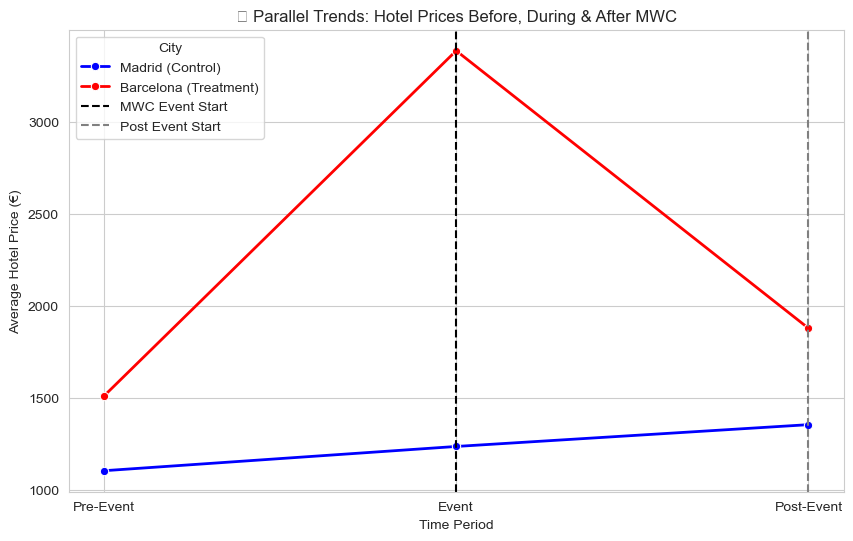

In [73]:
# Plot parallel trends

# Set plot style
sns.set_style("whitegrid")

# Plot the trends
plt.figure(figsize=(10, 6))

# Line plot for hotel prices over time
sns.lineplot(
    data=trend_data,
    x="period",
    y="price_euros",
    hue="Barcelona",
    marker="o",
    linewidth=2,
    palette=["blue", "red"]  # Control in blue, Treatment in red
)

# Add vertical lines for event and post periods
plt.axvline(x=1, color="black", linestyle="--", label="MWC Event Start")
plt.axvline(x=2, color="gray", linestyle="--", label="Post Event Start")

# Labels and title
plt.title("📊 Parallel Trends: Hotel Prices Before, During & After MWC")
plt.xlabel("Time Period")
plt.ylabel("Average Hotel Price (€)")
plt.legend(title="City")
plt.xticks(ticks=[0, 1, 2], labels=["Pre-Event", "Event", "Post-Event"])
plt.grid(True)

# Show the plot
plt.show()


In [83]:
# Part - 3c

import pandas as pd
import statsmodels.formula.api as smf

# Define the DID formula with interaction terms including hotel rating
formula = """price_euros ~ Barcelona + Event + Barcelona:Event + rating + 
             Barcelona:Event:rating + C(quality_type) + quality_over_5 + 
             num_reviews + C(neighborhood) + max_tfidf_hotel + unique_tfidf_word_cnt"""

# Define required columns for analysis
required_columns = ["price_euros", "Barcelona", "Event", "rating", "quality_type", 
                    "quality_over_5", "num_reviews", "neighborhood", "max_tfidf_hotel", "unique_tfidf_word_cnt"]

# Drop missing values and reset index
data_clean = data.dropna(subset=required_columns).reset_index(drop=True)

# Ensure 'Event' is properly formatted as an integer
data_clean["Event"] = data_clean["Event"].astype(int)

# Create the DID interaction term
data_clean["DID"] = data_clean["Barcelona"] * data_clean["Event"]

# Create the DID interaction term with rating (hotel quality proxy)
data_clean["DID_Rating"] = data_clean["DID"] * data_clean["rating"]

# Ensure both Barcelona and Madrid exist in the dataset
if data_clean["Barcelona"].nunique() < 2:
    raise ValueError("The dataset does not contain both Barcelona (1) and Madrid (0) values.")

# Run the OLS regression for the full dataset
print("\n=== Regression for DID Model with Hotel Quality Impact ===")
model = smf.ols(formula, data=data_clean).fit()
print(model.summary())

# Extract the DID effect (coefficient of the interaction term)
did_effect = model.params.get('Barcelona:Event', 0)  # Get DID coefficient, default 0 if missing
did_quality_effect = model.params.get('Barcelona:Event:rating', 0)  # DID impact by rating

print(f"\nEstimated Difference-in-Differences (DID) Effect: {did_effect}")
print(f"Estimated DID Effect Modified by Hotel Rating: {did_quality_effect}")



=== Regression for DID Model with Hotel Quality Impact ===
                            OLS Regression Results                            
Dep. Variable:            price_euros   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     26.39
Date:                Wed, 05 Feb 2025   Prob (F-statistic):          2.45e-148
Time:                        21:53:23   Log-Likelihood:                -18074.
No. Observations:                2098   AIC:                         3.623e+04
Df Residuals:                    2059   BIC:                         3.645e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------